In [1]:
import pandas as pd, numpy as np
import matplotlib.pyplot as plt, seaborn as sns

df = pd.read_csv("../data/Churn_Modelling.csv")
print(df.shape)
df.info()
df.head()

(10000, 14)
<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  str    
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  str    
 5   Gender           10000 non-null  str    
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), str(3)
memory usage: 1.2 MB


,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [2]:
print("Missing values:\n", df.isna().sum().sum())
print("Duplicate customers:", df["CustomerId"].duplicated().sum())
print(df["Exited"].value_counts())
print(f"Churn rate: {df['Exited'].mean():.1%}")

Missing values:
 0
Duplicate customers: 0
Exited
0    7963
1    2037
Name: count, dtype: int64
Churn rate: 20.4%


In [3]:
df = df.drop(columns=["RowNumber", "CustomerId", "Surname"])
df.describe().T

,count,mean,std,min,25%,50%,75%,max
CreditScore,10000.0,650.528800,96.653299,350.00,584.00,652.000,718.0000,850.00
Age,10000.0,38.921800,10.487806,18.00,32.00,37.000,44.0000,92.00
Tenure,10000.0,5.012800,2.892174,0.00,3.00,5.000,7.0000,10.00
Balance,10000.0,76485.889288,62397.405202,0.00,0.00,97198.540,127644.2400,250898.09
NumOfProducts,10000.0,1.530200,0.581654,1.00,1.00,1.000,2.0000,4.00
HasCrCard,10000.0,0.705500,0.455840,0.00,0.00,1.000,1.0000,1.00
IsActiveMember,10000.0,0.515100,0.499797,0.00,0.00,1.000,1.0000,1.00
EstimatedSalary,10000.0,100090.239881,57510.492818,11.58,51002.11,100193.915,149388.2475,199992.48
Exited,10000.0,0.203700,0.402769,0.00,0.00,0.000,0.0000,1.00


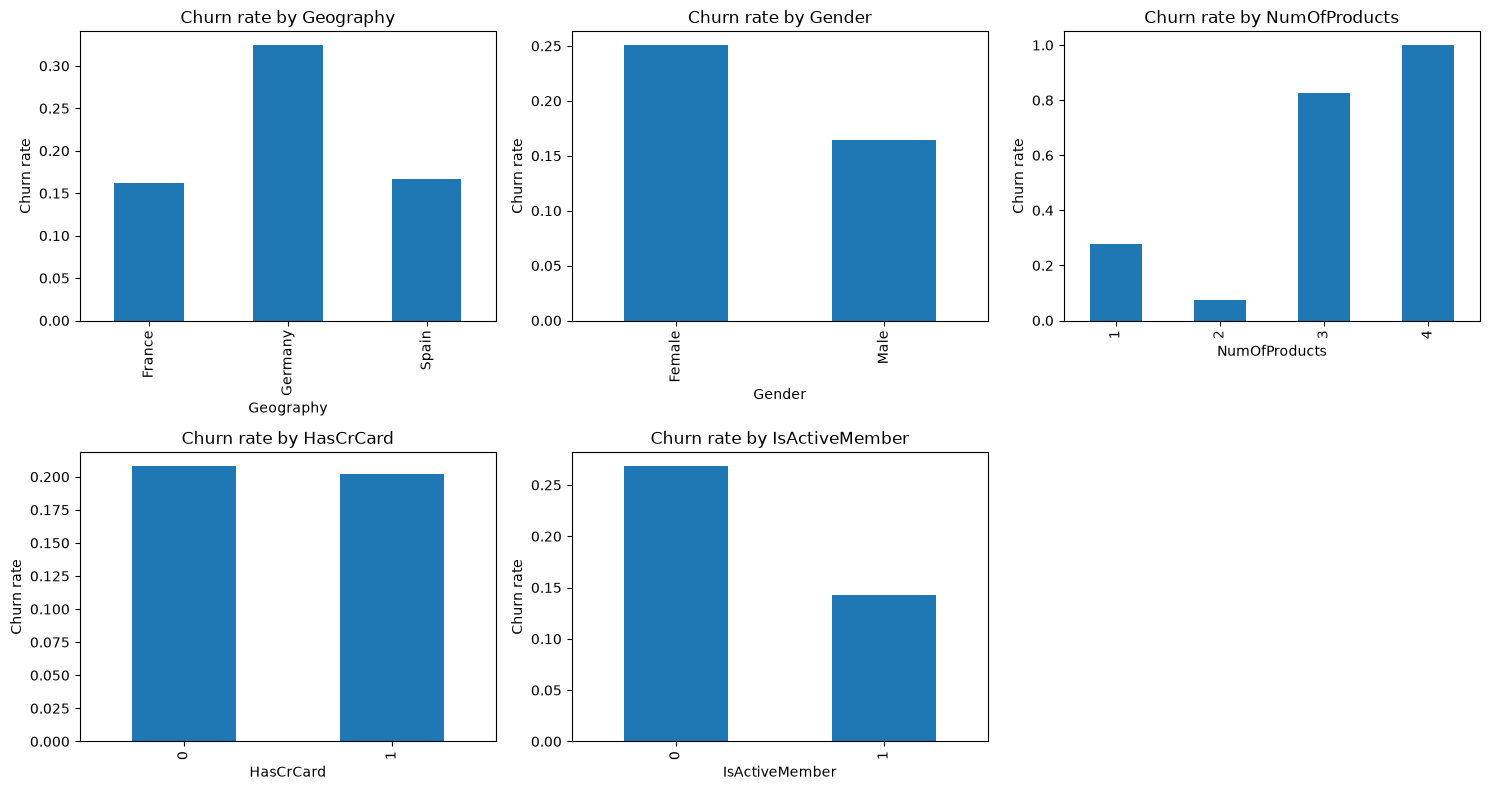

In [4]:
cats = ["Geography", "Gender", "NumOfProducts", "HasCrCard", "IsActiveMember"]
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, c in zip(axes.flat, cats):
    df.groupby(c)["Exited"].mean().plot(kind="bar", ax=ax)
    ax.set_title(f"Churn rate by {c}")
    ax.set_ylabel("Churn rate")
axes.flat[-1].axis("off")
plt.tight_layout(); plt.show()

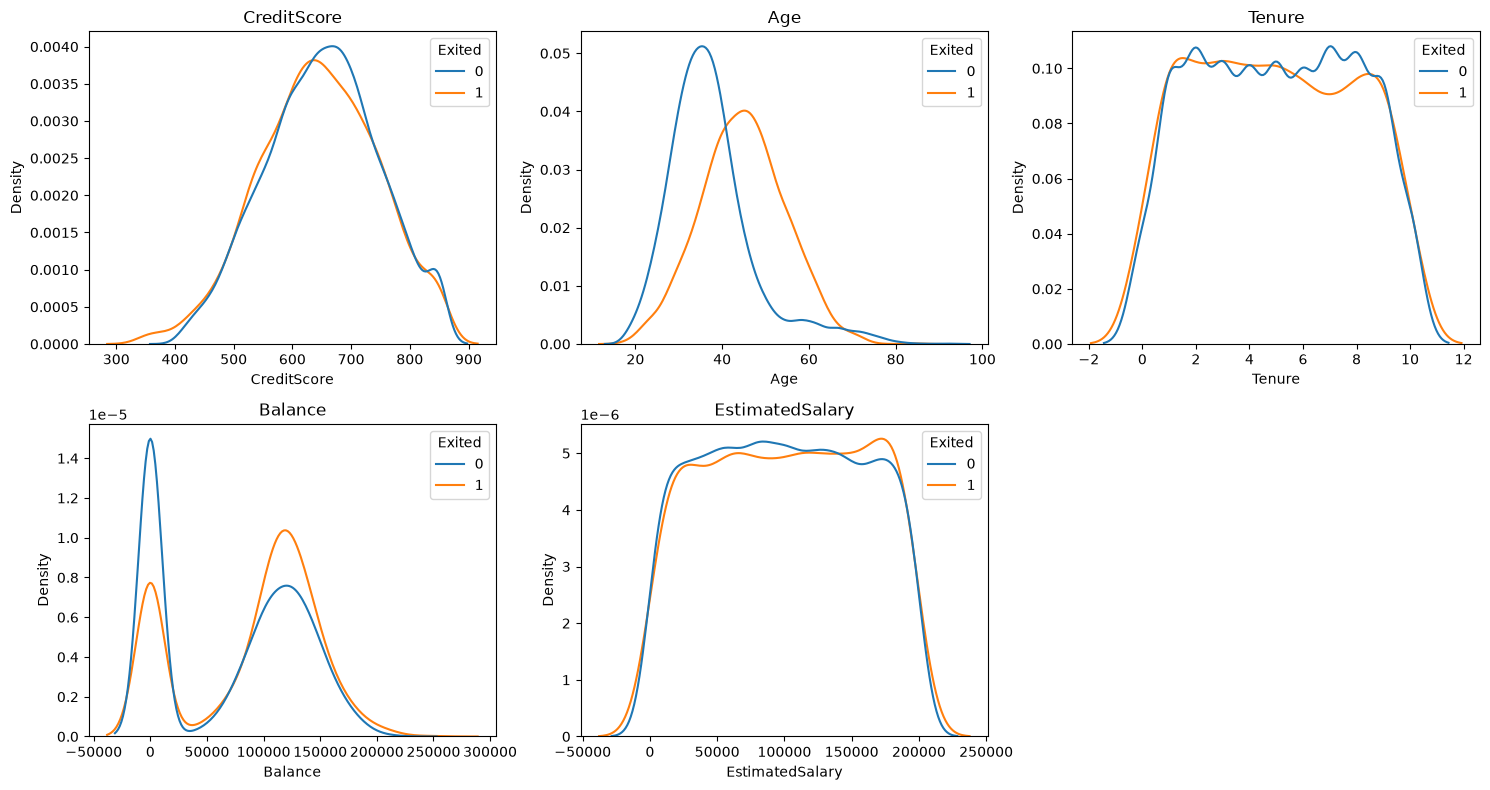

In [5]:
nums = ["CreditScore", "Age", "Tenure", "Balance", "EstimatedSalary"]
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, c in zip(axes.flat, nums):
    sns.kdeplot(data=df, x=c, hue="Exited", common_norm=False, ax=ax)
    ax.set_title(c)
axes.flat[-1].axis("off")
plt.tight_layout(); plt.show()

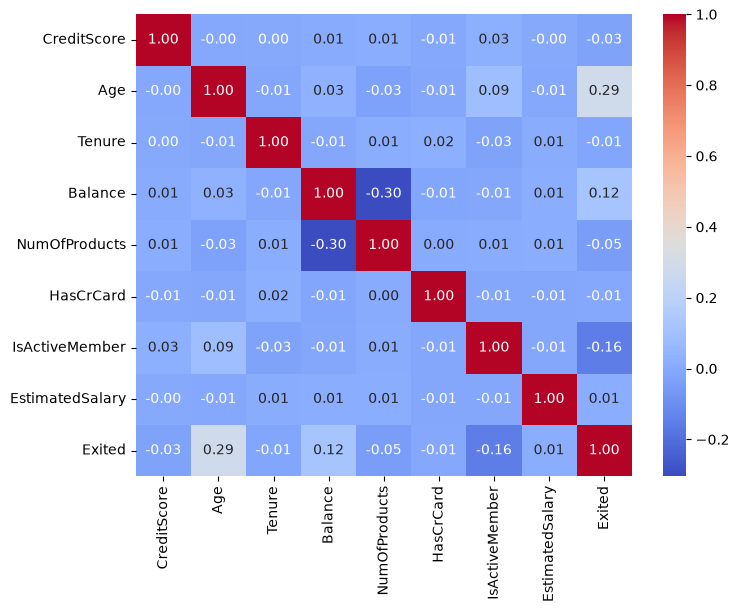

Share with zero balance: 0.362
Balance
False    0.240796
True     0.138236
Name: Exited, dtype: float64
Age
(17, 30]     0.075203
(30, 40]     0.120872
(40, 50]     0.339655
(50, 60]     0.562108
(60, 100]    0.247845
Name: Exited, dtype: float64


In [6]:
plt.figure(figsize=(8, 6))
sns.heatmap(df.select_dtypes("number").corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.show()

print("Share with zero balance:", (df["Balance"] == 0).mean().round(3))
print(df.groupby(df["Balance"] == 0)["Exited"].mean())
print(df.groupby(pd.cut(df["Age"], [17, 30, 40, 50, 60, 100]), observed=True)["Exited"].mean())